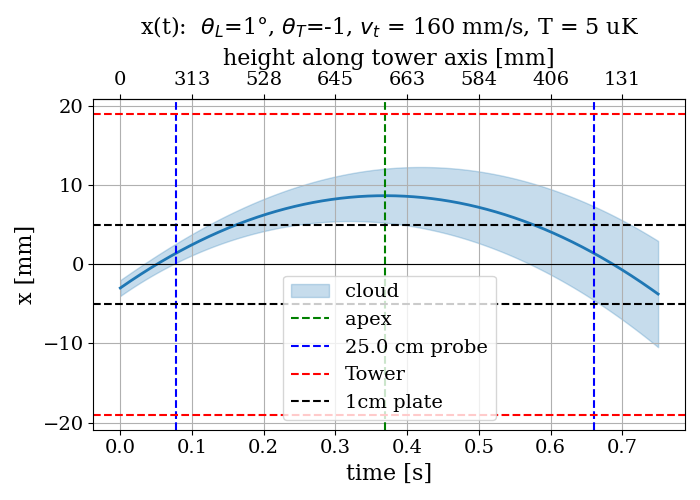

In [7]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

plt.close('all')
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=22)

# ---- constants ----
k_B  = 1.380649e-23          # J/K
m_cs = 132.90545 * 1.66053906660e-27   # kg

# ---- parameters ----
x0         = -.003      # initial x offset, m
vi_t       = 160      # track speed, mm/s
g          = 9.81     # m/s^2
d          = 0.038    # tower diameter, m

theta_l    = 1      # launch angle from axis, deg (cw +)
theta_t    = -1       # tower angle from vertical, deg (cw +)

d_cloud_i  = 2.0      # initial cloud diameter, mm
T          = 5      # cloud temperature, uK

t_max = .75           # s
t = np.linspace(0, t_max, 1000)

y_probe = 0.25

vi = 16 * np.sqrt(2) * vi_t / 1000

# ---- EOMs ----
thL = np.deg2rad(theta_l)
thT = np.deg2rad(theta_t)
x = x0 + vi * np.sin(thL) * t + 0.5 * g * np.sin(thT) * t**2
y = vi * np.cos(thL) * t - 0.5 * g * np.cos(thT) * t**2

# ---- cloud expansion in x ----
v_thermal = np.sqrt(k_B * (T * 1e-6) / m_cs)         # m/s
d_cloud   = np.sqrt((d_cloud_i * 1e-3)**2 + (v_thermal * t)**2)   # m
x_lo = x - d_cloud / 2
x_hi = x + d_cloud / 2

t_hit  = np.interp(d / 2, x, t)                      # centroid crosses +d/2
t_apex = vi * np.cos(thL) / (g * np.cos(thT))

# ---- plot ----
plt.figure(figsize=(7, 5))
#make shaded cloud
plt.fill_between(t, x_lo * 1e3, x_hi * 1e3, color='C0', alpha=0.25,
                 label='cloud')
plt.plot(t, x * 1e3, lw=2, color='C0')

#make point when CM hits the wall
if t_max > t_hit:
    plt.plot(t_hit, d / 2 * 1e3, 'ro', ms=8)
    plt.axvline(t_hit, color='r', lw=0.8, ls=':')
    plt.text(t_hit + 0.01, d / 2 * 1e3, f'{t_hit:.3f} s', color='red',
             rotation=90, va='top', ha='left', fontsize=14)
plt.axvline(t_apex, color='g', lw=1.5, ls='--', label = 'apex')

#show probe beam
a_y = vi * np.cos(thL)
b_y = 0.5 * g * np.cos(thT)
disc = a_y**2 - 4 * b_y * (y_probe)              # y_probe in meters
if disc >= 0:
    t_up   = (a_y - np.sqrt(disc)) / (2 * b_y)
    t_down = (a_y + np.sqrt(disc)) / (2 * b_y)
    plt.axvline(t_up,   color='b', lw=1.5, ls='--', label=f'{y_probe*100} cm probe')
    plt.axvline(t_down, color='b', lw=1.5, ls='--')

#make all axes
ax = plt.gca()
ax.set_xlabel('time [s]')
secax = ax.secondary_xaxis('top')
tick_t = ax.get_xticks()
secax.set_xticks(tick_t)
secax.set_xticklabels([f'{yy*1e3:.0f}' for yy in np.interp(tick_t, t, y)])
secax.set_xlabel('height along tower axis [mm]')
ax.set_ylabel('x [mm]')

plt.axhline(0, color='k', lw=0.8)
plt.axhline(d / 2 * 1e3, color='r', lw=1.5, ls='--', label = "Tower")
plt.axhline(-d / 2 * 1e3, color='r', lw=1.5, ls='--')
plt.axhline(0.005 * 1e3, color='k', lw=1.5, ls='--', label = "1cm plate")
plt.axhline(-0.005 * 1e3, color='k', lw=1.5, ls='--')

plt.title(f'x(t):  $\\theta_L$={theta_l}°, $\\theta_T$={theta_t}, $v_t$ = {vi_t} mm/s, T = {T} uK', pad = 10)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()